# 屈折を考慮して、見かけの位置でGaussianを移動させ、レンダリングする


In [1]:
import os
import torch
from gsplat import rasterization
import matplotlib.pyplot as plt
import sys
sys.path.append('..')  # Adjust the path as necessary to locate the gsplat root directory
from mine.loader import initialize_model_from_ply_file
from examples.datasets.blender_nerf_synthetic import Parser, Dataset
from refraction_utils_torch import RefractionSTE, culling_points_torch, transform_gaussians_torch

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2

device = torch.device("cuda:0")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [7]:
# Select the dataset
wo_refraction_dataset_path = os.path.abspath("../../../dataset/river1/river_wo-refraction")
with_refraction_dataset_path = os.path.abspath("../../../dataset/river1/river_with-refraction")
# Select trained model path
non_refraction_model_path = os.path.abspath('../results/favo/river_wo-refraction/ply/point_cloud_29999.ply')


In [8]:
# Load the dataset
parser_ref = Parser(
    data_dir=wo_refraction_dataset_path,
)
dataset_ref = Dataset(
    parser_ref,
    split="train",
)

dataloader_ref = torch.utils.data.DataLoader(
    dataset_ref,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    pin_memory=True,
)

Loading 3D point cloud from: /home/taiki/dataset/river1/river_wo-refraction/points3d.ply
[Parser] Loaded 61 images from /home/taiki/dataset/river1/river_wo-refraction.


In [9]:
data = dataloader_ref.dataset[12]

# extract data
camtoworlds_original = data["camtoworld"].to(device)
camtoworlds = data["camtoworld"].view(1,4,4).to(device)  # [1, 4, 4] 
Ks = data["K"].view(1,3,3).to(device)  # [1, 3, 3]
pixels = data["image"].unsqueeze(0).to(device) / 255.0  # [1, H, W, 3]
image_ids = data["image_id"]
height, width = pixels.shape[1:3]

image_name = "train", f"{image_ids:04d}" + ".png"
print(image_name)


('train', '0012.png')


In [10]:
# model adjustment
camtoworlds[:, 0, 3] *= -1
print(camtoworlds)

worldtocams = camtoworlds.inverse()
print(worldtocams)


tensor([[[ 1., -0., -0., -0.],
         [ 0., -1., -0.,  0.],
         [ 0., -0., -1., 30.],
         [ 0.,  0.,  0.,  1.]]], device='cuda:0')
tensor([[[ 1.0000,  0.0000,  0.0000,  0.0000],
         [ 0.0000, -1.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000, -1.0000, 30.0000],
         [ 0.0000,  0.0000,  0.0000,  1.0000]]], device='cuda:0')


In [11]:
# get Gaussian model from ply file
gs_model_gt = initialize_model_from_ply_file(non_refraction_model_path, device=device)

In [12]:
# get each parameters as tensor from Gaussian model  torch.from_numpy
means     = gs_model_gt.gaussians["means"]      # shape: [N, 3]
scales    = gs_model_gt.gaussians["scales"]     # shape: [N, 3]
quats     = gs_model_gt.gaussians["rotations"]  # shape: [N, 4]
opacities = gs_model_gt.gaussians["opacities"].squeeze(-1)   # shape: (N,)
colors    = gs_model_gt.gaussians["shs"]        # shape: [N, 16, 3]



# Refractionを考慮して座標変換

In [13]:
# --- メイン処理 ---
# 元のGaussian中心を numpy 配列に変換
# カメラ中心 (cam.T) はworld 座標。必要に応じ numpy 配列に変換
cam_center = camtoworlds[0, :3, 3].detach().clone()  # [3,]

# Get Gaussians in the camera frustum
mask = culling_points_torch(means, 
                      torch.inverse(camtoworlds),
                      Ks, 
                      width, 
                      height)

print(f"Culling: {torch.sum(mask)} / {mask.shape[0]} points are in the camera frustum")



Culling: 272981 / 1000000 points are in the camera frustum


/home/taiki/try-papers/gsplat/dev_refraction/refraction_utils_torch.py:145: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3614.)
  points_cam = (W2C @ points_h.T).T[:, :3]


In [16]:
# カリングされた点のみ屈折補正を実施
transformed_means, transformed_quats = transform_gaussians_torch(
    means[mask], 
    quats[mask], 
    cam_center, 
    n=1.33, 
    plane=0, 
    num_iters=10,
    tol=1e-3
)

# Recreate the splats with transformed means
refractive_means = torch.zeros_like(means)
refractive_means[mask] = transformed_means
refractive_means[~mask] = means[~mask]

# Recreate the splats with transformed quats
refractive_quats = torch.zeros_like(quats)
refractive_quats[mask] = transformed_quats
refractive_quats[~mask] = quats[~mask]


In [17]:
# 補正前の Gaussian を用いてレンダリング
rgb_wo_refraction, _, _ = rasterization(
    means,
    quats,
    scales,
    opacities,
    colors,
    camtoworlds,
    Ks,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_wo_refraction = rgb_wo_refraction.squeeze().cpu().detach().numpy()


In [18]:
# 補正後の Gaussian を用いてレンダリング
rgb_refraction, _, _ = rasterization(
    refractive_means,
    refractive_quats,
    scales,
    opacities,
    colors,
    camtoworlds,
    Ks,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_refraction = rgb_refraction.squeeze().cpu().detach().numpy()


GT image without refraction: /home/taiki/dataset/river1/river_wo-refraction/train/0012.png
GT image with refraction: /home/taiki/dataset/river1/river_with-refraction/train/0012.png


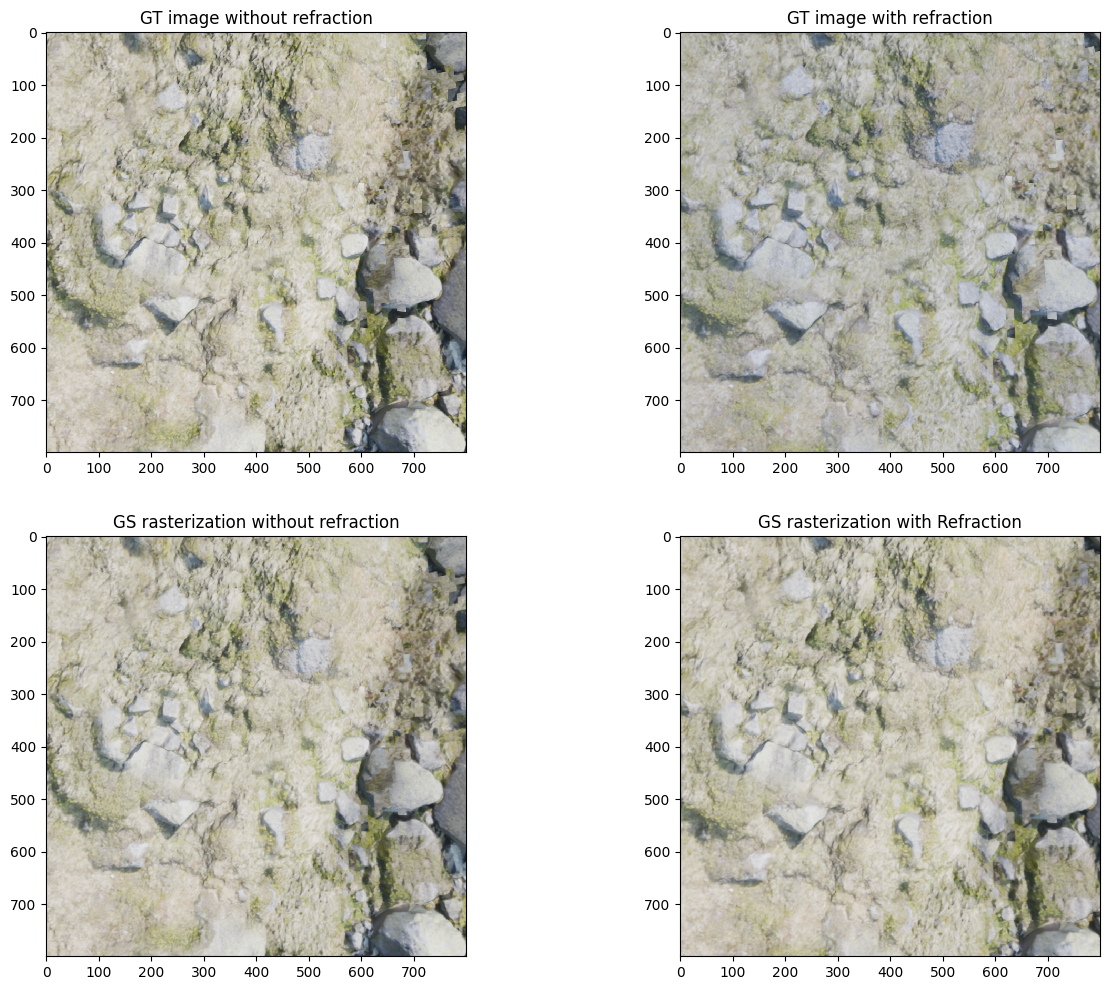

In [19]:
# Display
gt_image_path_wo_ref = os.path.join(wo_refraction_dataset_path, "train", f"{image_ids:04d}" + ".png")
gt_image_wo_ref = plt.imread(gt_image_path_wo_ref)
print(f"GT image without refraction: {gt_image_path_wo_ref}")

gt_image_path_with_ref = os.path.join(with_refraction_dataset_path, "train", f"{image_ids:04d}" + ".png")
gt_image_with_ref = plt.imread(gt_image_path_with_ref)
print(f"GT image with refraction: {gt_image_path_with_ref}")

fig, ax = plt.subplots(2, 2)
ax[0, 0].imshow(gt_image_wo_ref)
ax[0, 0].set_title("GT image without refraction")
ax[0, 1].imshow(gt_image_with_ref)
ax[0, 1].set_title("GT image with refraction")
ax[1, 0].imshow(rgb_wo_refraction)
ax[1, 0].set_title("GS rasterization without refraction")
ax[1, 1].imshow(rgb_refraction)
ax[1, 1].set_title("GS rasterization with Refraction")
plt.show()

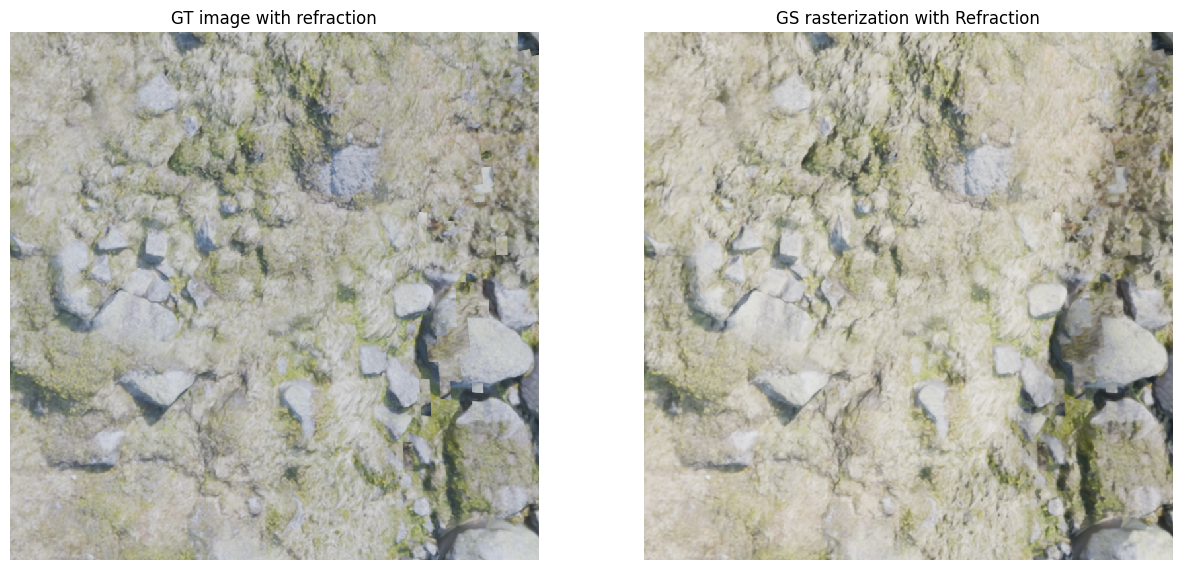

In [20]:
fig, ax = plt.subplots(1, 2)
# no axis
ax[0].axis("off")
ax[0].imshow(gt_image_with_ref)
ax[0].set_title("GT image with refraction")
ax[1].axis("off")
ax[1].imshow(rgb_refraction)
ax[1].set_title("GS rasterization with Refraction")

plt.show()

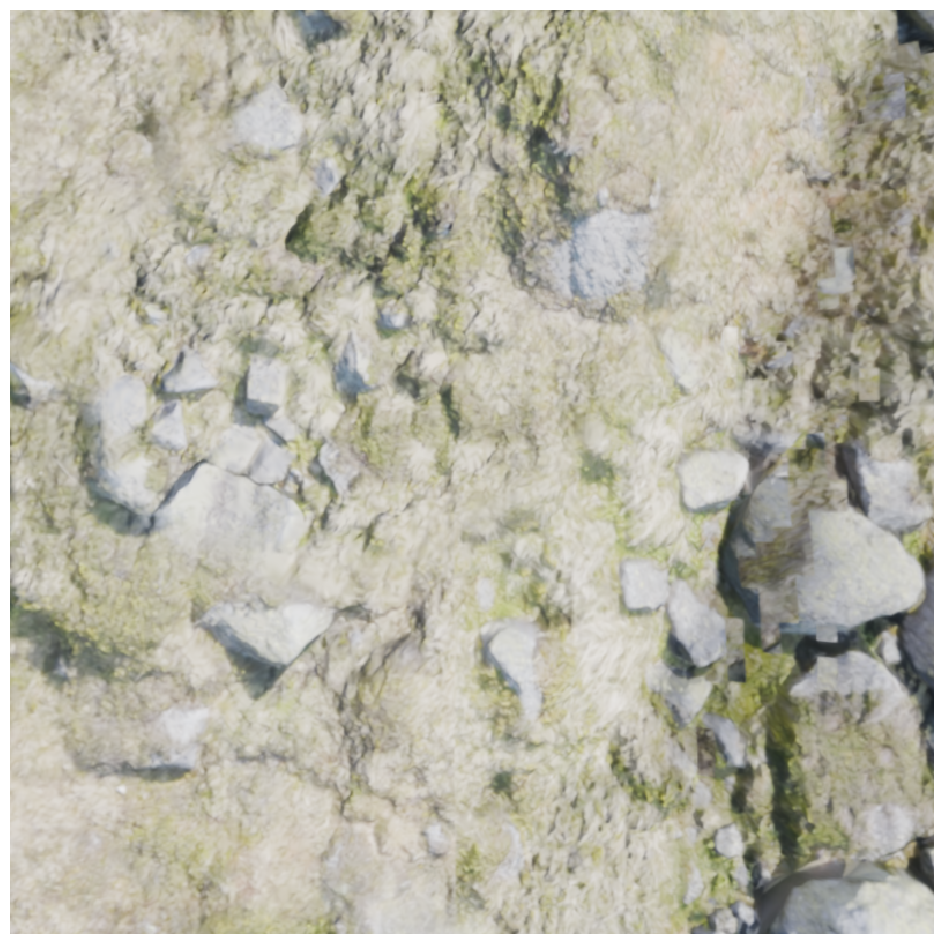

In [21]:
# show rgb_refraction
fig, ax = plt.subplots(1, 1)
ax.axis("off")
ax.imshow(rgb_refraction)
plt.show()